In [1]:
from pathlib import Path
from datetime import datetime, timedelta, date
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from unityvr.preproc import logproc as lp
from unityvr.analysis import posAnalysis, align2img
from gulp2p.preproc import utils, behavior
from gulp2p.preproc.tiff import Tiff
from gulp2p.config import BHV_DATA_RAW_DIR

config loaded


In [2]:
tiff_folder = Path(r"Z:\2PImaging\Kerstin\MIMS")
bhv_folder = BHV_DATA_RAW_DIR

## Compare tiff and bhv creation times

In [3]:
# do this for all bhv and tiffs in kerstins mimms folder
# Ignore time differences greater than 1 maybe 2 minutes (?)
# Need a way to synce up tiff and bhv files

In [4]:
def find_bhv_path_from_tiff(tiff_timestamp, bhv_folder=None):
    if bhv_folder is None:
        bhv_folder = Path(r"Z:\Live Fly Imaging data\unity\raw data")
    min_diff = None
    min_file = None
    for path in bhv_folder.rglob("*"):
        if not path.is_file():
            continue
        try:
            file_timestamp = utils.get_timestamp_from_string(path.name)
        except:
            continue

        time_diff = file_timestamp - tiff_timestamp
        if min_diff is None:
            min_diff = time_diff
            min_file = path
        if abs(time_diff) < abs(min_diff):
            min_diff = time_diff
            min_file = path
    return min_file, min_diff



In [5]:
tiff_paths = []
for path in tiff_folder.rglob("*"):
    if path.suffix != ".tif":
        continue
    if path.name in [p.name for p in tiff_paths]:
        continue
    tiff_paths.append(path)

df_dicts = []
for tiff_path in tiff_paths:
    tiff_date = Tiff(tiff_path).metadata['date']
    tiff_timestamp = tiff_date.timestamp()
    bhv_path, min_diff = find_bhv_path_from_tiff(tiff_timestamp)
    bhv_date = datetime.fromtimestamp(utils.get_timestamp_from_string(bhv_path.name))
    df_dicts.append({"tiff_date": tiff_date,
                     "bhv_date": bhv_date})
dates_df = pd.DataFrame(df_dicts)

dates_df['diff'] = dates_df['tiff_date'] - dates_df['bhv_date']

In [6]:
dates_df.head()

,tiff_date,bhv_date,diff
0,2023-11-17 16:21:05.428768,2023-11-20 12:56:35,-3 days +03:24:30.428768
1,2023-11-17 16:21:17.130715,2023-11-20 12:56:35,-3 days +03:24:42.130715
2,2023-11-17 16:21:17.986712,2023-11-20 12:56:35,-3 days +03:24:42.986712
3,2023-11-17 16:21:19.013707,2023-11-20 12:56:35,-3 days +03:24:44.013707
4,2023-11-17 16:21:19.808703,2023-11-20 12:56:35,-3 days +03:24:44.808703


In [7]:
# tiff is created about 33 seconds after bhv file
dates_df.describe()

,diff
count,190
mean,-1 days +22:12:40.377500148
std,0 days 11:00:41.055893704
min,-3 days +03:24:30.428768
25%,0 days 00:00:17.797629250
50%,0 days 00:00:33.714027
75%,0 days 00:01:22.524943750
max,0 days 00:14:44.321816


In [8]:
dates_df_filtered = dates_df[(dates_df["diff"] < timedelta(minutes=5)) & (dates_df["diff"] > timedelta(minutes=-5))]

In [9]:
dates_df_filtered.describe()

,diff
count,168
mean,0 days 00:00:37.140537553
std,0 days 00:01:03.012456622
min,-1 days +23:55:56.290211
25%,0 days 00:00:17.812803750
50%,0 days 00:00:27.592739500
75%,0 days 00:01:17.835057500
max,0 days 00:03:51.574860


In [10]:
dates_df_filtered

,tiff_date,bhv_date,diff
5,2023-11-28 18:20:46.428184,2023-11-28 18:20:40,0 days 00:00:06.428184
6,2023-11-28 18:20:53.709270,2023-11-28 18:20:40,0 days 00:00:13.709270
7,2023-11-28 18:21:00.975357,2023-11-28 18:20:40,0 days 00:00:20.975357
8,2023-11-28 18:21:08.250443,2023-11-28 18:20:40,0 days 00:00:28.250443
9,2023-11-28 18:21:15.534530,2023-11-28 18:20:40,0 days 00:00:35.534530
...,...,...,...
185,2024-02-15 13:53:57.157975,2024-02-15 13:52:28,0 days 00:01:29.157975
186,2024-02-15 13:59:32.872966,2024-02-15 14:00:03,-1 days +23:59:29.872966
187,2024-02-15 14:01:31.519963,2024-02-15 14:00:03,0 days 00:01:28.519963
188,2024-02-15 14:07:45.325953,2024-02-15 14:06:17,0 days 00:01:28.325953


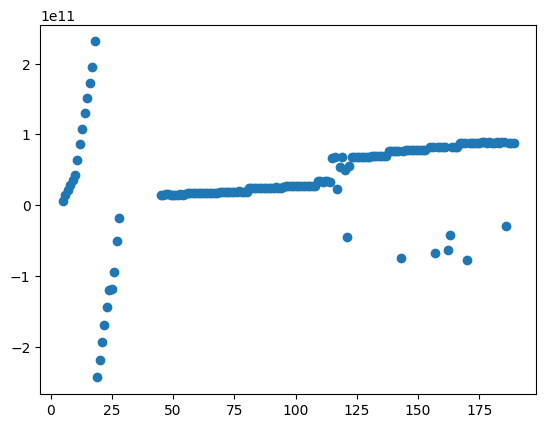

In [11]:
ax = plt.subplot()
ax.scatter(dates_df_filtered.index, dates_df_filtered['diff'])

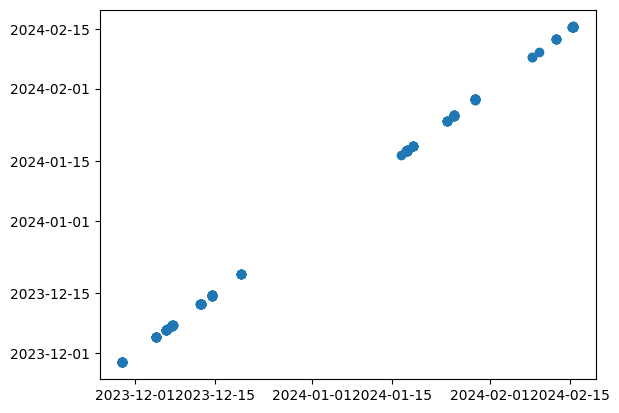

In [12]:
plt.scatter(dates_df_filtered['tiff_date'], dates_df_filtered['bhv_date'])

## Plot recording intervals over an experiment

In [13]:
def convert_interval_units(time_interval):
    # Convert from timestamp to minutes since midnight
    date_day = date.fromtimestamp(time_interval[0])
    new_interval = []
    for timepoint in time_interval:
        midnight_timestamp = datetime.combine(date_day, datetime.min.time()).timestamp()
        seconds_since_midnight = timepoint - midnight_timestamp
        hour_since_midnight = seconds_since_midnight / 60 / 60
        new_interval.append(hour_since_midnight)
    return new_interval

In [14]:
def get_tiff_interval(tiff):
    tiff_start_time = tiff.metadata['date'].timestamp()
    tiff_length = tiff.length
    tiff_interval = (tiff_start_time, tiff_start_time + tiff_length)
    return tiff_interval

def get_bhv_interval(bhv_path):
    bhv_start_time = utils.get_timestamp_from_string(bhv_path.name)
    bhv_length = utils.get_bhv_length(bhv_path)
    if bhv_length is None:
        bhv_length = 0
    bhv_interval = (bhv_start_time, bhv_start_time + bhv_length)
    return bhv_interval

In [15]:
def plot_interval(interval, ax, y, color="C0"):
    ax.plot(interval, [y,y], c=color, marker='o', ms=2)

def plot_intervals(intervals, ax, y, color="C0", dodge=0.1):
    for index, interval in enumerate(intervals):
        if index % 2 == 0:
            jitter = 1 * dodge
        else:
            jitter = -1 * dodge
        plot_interval(interval, ax, y=y+jitter, color=color)

In [16]:
df_dicts = []
for path in tiff_folder.rglob("*"):
    if path.suffix != ".tif":
        continue
    if path.name in [row['path'].name for row in df_dicts]:
        continue
    tiff = Tiff(path)
    df_dicts.append({"path": path,
                     "tiff": tiff,
                     "datetime": tiff.metadata['date']})

tiff_df = pd.DataFrame(df_dicts)

In [17]:
tiff_df['date'] = tiff_df['datetime'].apply(lambda x:x.date())
tiff_df['interval'] = tiff_df['tiff'].apply(get_tiff_interval)
tiff_df['interval_sub_midnight'] = tiff_df['interval'].apply(convert_interval_units)

In [18]:
tiff_df.head()

,path,tiff,datetime,date,interval,interval_sub_midnight
0,Z:\2PImaging\Kerstin\MIMS\20231109\Fly1_8days_...,<gulp2p.preproc.tiff.Tiff object at 0x00000136...,2023-11-17 16:21:05.428768,2023-11-17,"(1700266865.428768, 1700267065.4843678)","[16.35150799108876, 16.407078991068733]"
1,Z:\2PImaging\Kerstin\MIMS\20231109\Fly1_8days_...,<gulp2p.preproc.tiff.Tiff object at 0x00000136...,2023-11-17 16:21:17.130715,2023-11-17,"(1700266877.130715, 1700266928.6563148)","[16.35475853191482, 16.369071198569404]"
2,Z:\2PImaging\Kerstin\MIMS\20231109\Fly1_8days_...,<gulp2p.preproc.tiff.Tiff object at 0x00000136...,2023-11-17 16:21:17.986712,2023-11-17,"(1700266877.986712, 1700266929.5126119)","[16.35499630888303, 16.369309058851666]"
3,Z:\2PImaging\Kerstin\MIMS\20231109\Fly1_8days_...,<gulp2p.preproc.tiff.Tiff object at 0x00000136...,2023-11-17 16:21:19.013707,2023-11-17,"(1700266879.013707, 1700266930.538707)","[16.355281585256257, 16.36959408528275]"
4,Z:\2PImaging\Kerstin\MIMS\20231109\Fly1_8days_...,<gulp2p.preproc.tiff.Tiff object at 0x00000136...,2023-11-17 16:21:19.808703,2023-11-17,"(1700266879.808703, 1700267199.2730029)","[16.355502417484917, 16.44424250079526]"


In [19]:
df_dicts = []
for path in bhv_folder.rglob("*"):
    if path.suffix != ".json":
        continue
    if path.stem == "SessionParameters":
        continue
    if path.name in [row['path'].name for row in df_dicts]:
        continue
    bhv_timestamp = utils.get_timestamp_from_string(path.name)
    bhv_datetime = datetime.fromtimestamp(bhv_timestamp)
    df_dicts.append({"path": path,
                     "datetime": bhv_datetime})

bhv_df = pd.DataFrame(df_dicts)

In [20]:
bhv_df['date'] = bhv_df['datetime'].apply(lambda x:x.date())
bhv_df['interval'] = bhv_df['path'].apply(get_bhv_interval)
bhv_df['interval_sub_midnight'] = bhv_df['interval'].apply(convert_interval_units)

In [21]:
bhv_df.head()

,path,datetime,date,interval,interval_sub_midnight
0,Z:\Live Fly Imaging data\unity\raw data\Backup...,2022-12-13 10:49:54,2022-12-13,"(1670957394.0, 1670957993.446289)","[10.831666666666667, 10.998179524739584]"
1,Z:\Live Fly Imaging data\unity\raw data\Backup...,2022-12-13 11:09:47,2022-12-13,"(1670958587.0, 1670959186.4534302)","[11.163055555555555, 11.32957039727105]"
2,Z:\Live Fly Imaging data\unity\raw data\Backup...,2022-12-13 11:35:09,2022-12-13,"(1670960109.0, 1670960708.4599)","[11.585833333333333, 11.752349972195097]"
3,Z:\Live Fly Imaging data\unity\raw data\Backup...,2022-12-14 10:18:55,2022-12-14,"(1671041935.0, 1671042534.2382812)","[10.315277777777776, 10.481732855902777]"
4,Z:\Live Fly Imaging data\unity\raw data\Backup...,2022-12-14 10:29:39,2022-12-14,"(1671042579.0, 1671043178.4607544)","[10.494166666666667, 10.66068354288737]"


In [22]:
def shift_intervals(intervals, shift):
    shifted_intervals = []
    for interval in intervals:
        shifted = [point + shift for point in interval]
        shifted_intervals.append(shifted)
    return shifted_intervals

def get_overlapping_intervals(main_intervals, secondary_intervals):
    overlapping_intervals = []
    for main_interval in main_intervals:
        for secondary_interval in secondary_intervals:
            interval_overlap = utils.get_overlap(main_interval, secondary_interval)
            if interval_overlap is None:
                continue
            overlapping_intervals.append(interval_overlap)
    return overlapping_intervals

def deduplicate_intervals(intervals):
    sorted_intervals = sorted(intervals, key=lambda x: x[0])
    i = 0
    while (i < len(sorted_intervals)-1):
        interval = sorted_intervals[i]
        next_interval = sorted_intervals[i+1]
        start_point = interval[0]
        if next_interval[0] <= interval[1]:
            end_point = max(interval[1], next_interval[1])
            combined_interval = [start_point, end_point]
            sorted_intervals[i:i+1+1] = [combined_interval]
        else:
            i += 1
    return sorted_intervals

def get_length_of_intervals(intervals):
    length = 0
    for interval in intervals:
        length += interval[1] - interval[0]
    return length

def calculate_coverage(main_intervals, secondary_intervals, with_duplicates=False):
    overlapping_intervals = get_overlapping_intervals(main_intervals, secondary_intervals)
    if not with_duplicates:
        overlapping_intervals = deduplicate_intervals(overlapping_intervals)

    covered_length = get_length_of_intervals(overlapping_intervals)
    total_length = get_length_of_intervals(main_intervals)
    coverage = covered_length / total_length
    return coverage

In [23]:
def plot_expt_file_intervals(expt_date, tiff_df, bhv_df, ax, with_overlaps=False):

    tiff_df_subset = tiff_df[tiff_df['date'] == expt_date]
    bhv_df_subset = bhv_df[bhv_df['date'] == expt_date]

    # plot all intervals and see if they can be aligned by shifting
    tiff_intervals = list(tiff_df_subset['interval_sub_midnight'])
    bhv_intervals = list(bhv_df_subset['interval_sub_midnight'])
    plot_intervals(tiff_intervals, ax, y=1, color="C0")
    plot_intervals(bhv_intervals, ax, y=2, color="C1")
    ax.set_ylim([0.5, 2.5])
    if with_overlaps:
        overlaps = get_overlapping_intervals(tiff_intervals, bhv_intervals)
        deduplicated_overlaps = deduplicate_intervals(overlaps)
        plot_intervals(overlaps, ax, y=3, color="C2")
        plot_intervals(deduplicated_overlaps, ax, y=4, color="C3")
        ax.set_ylim([0.5, 2.5+2])
    ax.set_yticks([1, 2], ["tiff", "bhv"])
    ax.set_title(expt_date)

    min_diffs = []
    for i, tiff_row in tiff_df_subset.iterrows():
        # print(tiff_row['path'].name)
        tiff_ts = tiff_row['datetime'].timestamp()
        min_diff = None
        for j, bhv_row in bhv_df_subset.iterrows():
            bhv_ts = bhv_row['datetime'].timestamp()
            diff = bhv_ts - tiff_ts
            if min_diff is None:
                min_diff = diff
            if diff > 0:
                continue
            if abs(diff) < abs(min_diff):
                min_diff = diff
                bhv_path = bhv_row['path']
        min_diffs.append(min_diff)
    try:
        mean = np.mean(min_diffs)
        std = np.std(min_diffs)
        ax.text(x=0.5, y=0.5, s=f"mean: {mean}, std: {std}",
                ha='center', va='center', transform=ax.transAxes)
    except:
        pass

    return ax

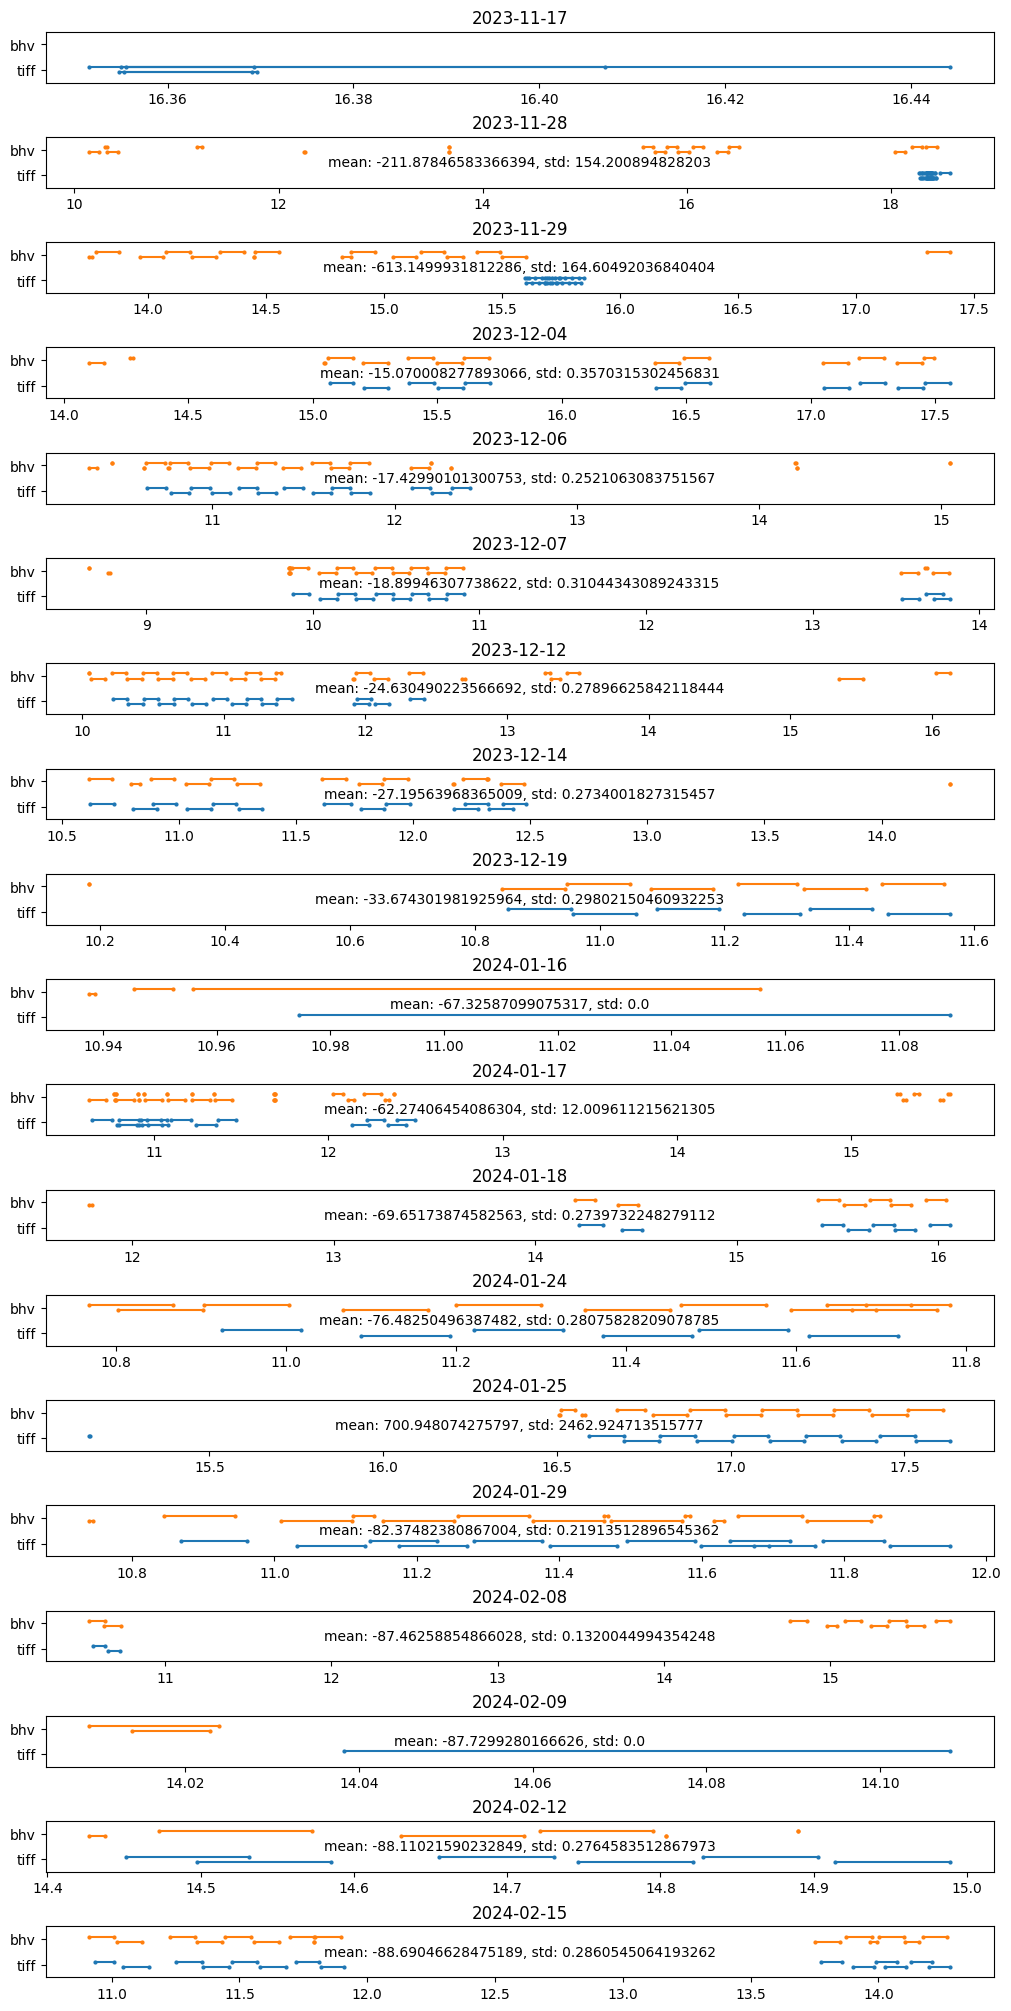

In [24]:
expt_dates = tiff_df['date'].unique()
fig, axs = plt.subplots(len(expt_dates), figsize=(10,20), layout="constrained")
for index, expt_date in enumerate(expt_dates):
    plot_expt_file_intervals(expt_date, tiff_df, bhv_df, axs[index])

In [25]:
# Is the delay for any given day the same?
# If so I can use that to align the tiff and behavioral data

### Check if the delay between tiff and bhv creation date is consistent during one recording session.

In [26]:
expt_date = date.fromisoformat("2024-01-24")
tiff_df_subset = tiff_df[tiff_df['date'] == expt_date]
bhv_df_subset = bhv_df[bhv_df['date'] == expt_date]

<Axes: title={'center': '2024-01-24'}>

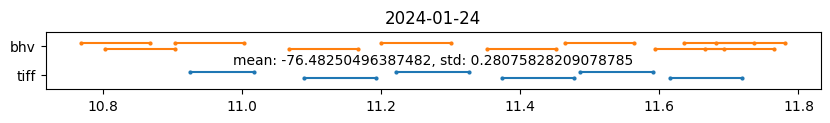

In [27]:
fig, ax = plt.subplots(figsize=(10,0.75))
plot_expt_file_intervals(expt_date, tiff_df, bhv_df, ax)

In [28]:
tiff_df_subset

,path,tiff,datetime,date,interval,interval_sub_midnight
138,Z:\2PImaging\Kerstin\MIMS\20240124\20240124_DR...,<gulp2p.preproc.tiff.Tiff object at 0x00000136...,2024-01-24 10:55:27.349428,2024-01-24,"(1706122527.349428, 1706122862.2380688)","[10.924263729982906, 11.017288352449734]"
139,Z:\2PImaging\Kerstin\MIMS\20240124\20240124_DR...,<gulp2p.preproc.tiff.Tiff object at 0x00000136...,2024-01-24 11:05:17.823446,2024-01-24,"(1706123117.823446, 1706123494.7796724)","[11.088284290565385, 11.192994353440072]"
140,Z:\2PImaging\Kerstin\MIMS\20240124\20240124_DR...,<gulp2p.preproc.tiff.Tiff object at 0x00000136...,2024-01-24 11:13:15.311121,2024-01-24,"(1706123595.311121, 1706123972.2783194)","[11.220919755829705, 11.325632866488563]"
141,Z:\2PImaging\Kerstin\MIMS\20240124\20240124_DR...,<gulp2p.preproc.tiff.Tiff object at 0x00000136...,2024-01-24 11:22:23.022630,2024-01-24,"(1706124143.02263, 1706124519.9854395)","[11.373061841660075, 11.477773733205265]"
142,Z:\2PImaging\Kerstin\MIMS\20240124\20240124_DR...,<gulp2p.preproc.tiff.Tiff object at 0x00000136...,2024-01-24 11:29:07.759440,2024-01-24,"(1706124547.75944, 1706124924.746388)","[11.485488733318116, 11.59020732998848]"
143,Z:\2PImaging\Kerstin\MIMS\20240124\20240124_DR...,<gulp2p.preproc.tiff.Tiff object at 0x00000136...,2024-01-24 11:36:52.628965,2024-01-24,"(1706125012.628965, 1706125389.6181073)","[11.614619156916937, 11.719338363144134]"


In [29]:
bhv_df_subset

,path,datetime,date,interval,interval_sub_midnight
567,Z:\Live Fly Imaging data\unity\raw data\Backup...,2024-01-24 11:40:53,2024-01-24,"(1706125253.0, 1706125612.2337646)","[11.681388888888888, 11.781176045735679]"
568,Z:\Live Fly Imaging data\unity\raw data\Backup...,2024-01-24 11:39:55,2024-01-24,"(1706125195.0, 1706125554.2461548)","[11.665277777777778, 11.765068376329209]"
569,Z:\Live Fly Imaging data\unity\raw data\Backup...,2024-01-24 11:38:08,2024-01-24,"(1706125088.0, 1706125447.2528687)","[11.635555555555555, 11.735348019070097]"
570,Z:\Live Fly Imaging data\unity\raw data\Backup...,2024-01-24 11:35:36,2024-01-24,"(1706124936.0, 1706125295.2893066)","[11.593333333333334, 11.693135918511285]"
571,Z:\Live Fly Imaging data\unity\raw data\Backup...,2024-01-24 11:27:51,2024-01-24,"(1706124471.0, 1706124830.2649841)","[11.464166666666667, 11.563962495591905]"
572,Z:\Live Fly Imaging data\unity\raw data\Backup...,2024-01-24 11:21:07,2024-01-24,"(1706124067.0, 1706124426.2813416)","[11.351944444444445, 11.451744817097982]"
573,Z:\Live Fly Imaging data\unity\raw data\Backup...,2024-01-24 11:11:59,2024-01-24,"(1706123519.0, 1706123878.282318)","[11.199722222222222, 11.299522866143121]"
574,Z:\Live Fly Imaging data\unity\raw data\Backup...,2024-01-24 11:04:01,2024-01-24,"(1706123041.0, 1706123400.2832947)","[11.066944444444443, 11.166745359632703]"
575,Z:\Live Fly Imaging data\unity\raw data\Backup...,2024-01-24 10:54:11,2024-01-24,"(1706122451.0, 1706122810.261078)","[10.903055555555556, 11.002850299411351]"
576,Z:\Live Fly Imaging data\unity\raw data\Backup...,2024-01-24 10:48:10,2024-01-24,"(1706122090.0, 1706122449.258545)","[10.802777777777777, 10.902571818033854]"


In [30]:
min_diffs = []
for i, tiff_row in tiff_df_subset.iterrows():
    tiff_ts = tiff_row['datetime'].timestamp()
    min_diff = None
    for j, bhv_row in bhv_df_subset.iterrows():
        bhv_ts = bhv_row['datetime'].timestamp()
        diff = bhv_ts - tiff_ts
        if min_diff is None:
            min_diff = diff
        if diff > 0:
            continue
        if abs(diff) < abs(min_diff):
            min_diff = diff
            bhv_path = bhv_row['path']
    min_diffs.append(min_diff)

print(np.mean(min_diffs))
print(np.std(min_diffs))

-76.48250496387482
0.28075828209078785


## Align behavior data to tiffs

<Axes: title={'center': '2024-01-25'}>

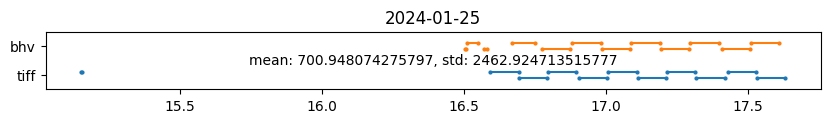

In [41]:
expt_date = date.fromisoformat("2024-01-25")

fig, ax = plt.subplots(figsize=(10,0.75))
plot_expt_file_intervals(expt_date, tiff_df, bhv_df, ax)

In [42]:
df_dicts = []
tiff_intervals = tiff_df_subset['interval']
bhv_intervals = bhv_df_subset['interval']
for tiff_interval in tiff_intervals:
    for bhv_interval in bhv_intervals:
        # Shift bhv file start to tiffs starting point
        shift = tiff_interval[0] - bhv_interval[0]
        shifted_bhv_intervals = shift_intervals(bhv_intervals, shift)
        coverage = calculate_coverage(tiff_intervals, shifted_bhv_intervals)
        coverage_with_dup = calculate_coverage(tiff_intervals, shifted_bhv_intervals, with_duplicates=True)
        df_dicts.append({"shift": shift,
                         "coverage": coverage,
                         "coverage_with_dup": coverage_with_dup})

coverage_df = pd.DataFrame(df_dicts)

In [43]:
tiff_df_subset = tiff_df[tiff_df['date'] == expt_date]
bhv_df_subset = bhv_df[bhv_df['date'] == expt_date]

In [44]:
for path in tiff_df_subset['path']:
    print(path)

Z:\2PImaging\Kerstin\MIMS\20240125\20240125_DR019xiGluSnFR_Fly02_00002.tif
Z:\2PImaging\Kerstin\MIMS\20240125\20240125_DR019xiGluSnFR_Fly02_00004.tif
Z:\2PImaging\Kerstin\MIMS\20240125\20240125_DR019xiGluSnFR_Fly02_00005.tif
Z:\2PImaging\Kerstin\MIMS\20240125\20240125_DR019xiGluSnFR_Fly02_00006.tif
Z:\2PImaging\Kerstin\MIMS\20240125\20240125_DR019xiGluSnFR_Fly02_00007.tif
Z:\2PImaging\Kerstin\MIMS\20240125\20240125_DR019xiGluSnFR_Fly02_00008.tif
Z:\2PImaging\Kerstin\MIMS\20240125\20240125_DR019xiGluSnFR_Fly02_00009.tif
Z:\2PImaging\Kerstin\MIMS\20240125\20240125_DR019xiGluSnFR_Fly02_00010.tif
Z:\2PImaging\Kerstin\MIMS\20240125\20240125_DR019xiGluSnFR_Fly02_00011.tif
Z:\2PImaging\Kerstin\MIMS\20240125\20240125_DR019xiGluSnFR_Fly02_00012.tif
Z:\2PImaging\Kerstin\MIMS\20240125\test_20240125_DR019xiGluSnFR_Fly01_00001.tif


In [45]:
for path in bhv_df_subset['path']:
    print(path)

Z:\Live Fly Imaging data\unity\raw data\Backups\Log_2024-01-25_17-30-38.json
Z:\Live Fly Imaging data\unity\raw data\Backups\Log_2024-01-25_17-24-27.json
Z:\Live Fly Imaging data\unity\raw data\Backups\Log_2024-01-25_17-17-52.json
Z:\Live Fly Imaging data\unity\raw data\Backups\Log_2024-01-25_17-11-39.json
Z:\Live Fly Imaging data\unity\raw data\Backups\Log_2024-01-25_17-05-26.json
Z:\Live Fly Imaging data\unity\raw data\Backups\Log_2024-01-25_16-59-12.json
Z:\Live Fly Imaging data\unity\raw data\Backups\Log_2024-01-25_16-52-57.json
Z:\Live Fly Imaging data\unity\raw data\Backups\Log_2024-01-25_16-46-30.json
Z:\Live Fly Imaging data\unity\raw data\Backups\Log_2024-01-25_16-40-17.json
Z:\Live Fly Imaging data\unity\raw data\Backups\Log_2024-01-25_16-34-18.json
Z:\Live Fly Imaging data\unity\raw data\Backups\Log_2024-01-25_16-30-42.json
Z:\Live Fly Imaging data\unity\raw data\Backups\Log_2024-01-25_16-30-18.json


best shift: 88.7322518825531
coverage: 0.9279397433966812


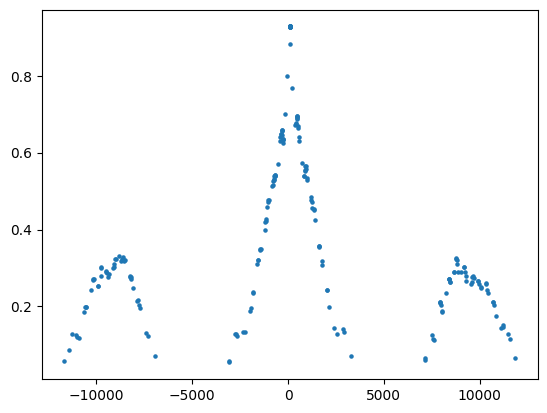

In [46]:
ax = plt.scatter(coverage_df['shift'], coverage_df['coverage'], s=5)
best_row = coverage_df.loc[coverage_df['coverage'].idxmax()]
print(f"best shift: {best_row['shift']}")
print(f"coverage: {best_row['coverage']}")
pass

In [55]:
coverage_df[coverage_df['coverage']>coverage_df['coverage'].quantile(0.90)].sort_values('coverage')

,shift,coverage,coverage_with_dup
15,483.732252,0.693140,0.745607
63,491.459210,0.693988,0.744729
79,488.496200,0.694204,0.745607
194,-166.674047,0.700361,0.751303
176,207.519963,0.768984,0.823860
162,-30.127034,0.798889,0.853120
112,110.454176,0.881919,0.926660
0,89.271262,0.927508,0.980618
145,89.157975,0.927635,0.980795
193,88.325953,0.927805,0.981167


In [48]:
coverage_df.describe()

,shift,coverage,coverage_with_dup
count,210.000000,210.000000,210.000000
mean,256.738085,0.384148,0.408099
std,6610.580773,0.231061,0.245084
min,-11665.728738,0.054373,0.055119
25%,-2600.517748,0.221925,0.245496
50%,88.626107,0.302542,0.324829
75%,7144.443987,0.539458,0.587066
max,11843.345946,0.927940,0.981306


In [49]:
# Get shift with max coverage
best_shift = coverage_df.loc[coverage_df['coverage'].idxmax(), "shift"]

In [50]:
best_shift

88.7322518825531

### Plot overlaps

<Axes: title={'center': '2024-01-24'}>

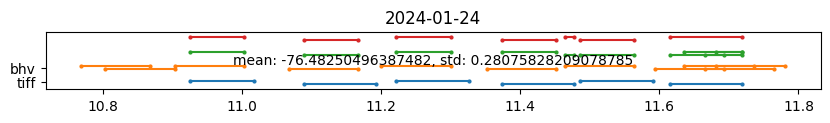

In [51]:
expt_date = date.fromisoformat("2024-01-24")

fig, ax = plt.subplots(figsize=(10,0.75))
plot_expt_file_intervals(expt_date, tiff_df, bhv_df, ax, with_overlaps=True)